In [1]:
IN_PATH = "mobile-restraints-test-2.nanover.zip"
PREFIX = "interaction.MOVEABLE-RESTRAINT"

In [2]:
import numpy as np

In [3]:
from dataclasses import dataclass, field
from nanover.recording import NanoverRecordingReader


@dataclass(kw_only=True)
class Group:
    key: str
    particles: list[int]
    moves: list[tuple[int, list]] = field(default_factory=list)


GROUPS = dict[str, Group]


with NanoverRecordingReader.from_path(IN_PATH) as reader:
    index: dict[str, set[int]] = {}

    for entry, update in reader.iter_state_updates():
        for key in update.updates.keys():
            if key.startswith(PREFIX):
                index[key] = [int(i) for i in update.updates[key]["particles"]]

    GROUPS = { key: Group(key=key, particles=value) for key, value in index.items() }

print("\n".join(str(v) for v in GROUPS.values()))

Group(key='interaction.MOVEABLE-RESTRAINT.2', particles=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], moves=[])
Group(key='interaction.MOVEABLE-RESTRAINT.1', particles=[162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172], moves=[])
Group(key='interaction.MOVEABLE-RESTRAINT.3', particles=[72, 73, 74, 75, 76, 77, 78, 79, 80, 81], moves=[])
Group(key='interaction.MOVEABLE-RESTRAINT.4', particles=[102, 103, 104, 105, 106, 107, 108, 109, 110, 111], moves=[])
Group(key='interaction.MOVEABLE-RESTRAINT.5', particles=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51], moves=[])


In [4]:
from nanover.trajectory import FrameData
from nanover.utilities.state_dictionary import DictionaryChange

with NanoverRecordingReader.from_path(IN_PATH) as reader:
    group = list(GROUPS.values())[0]
    paths = []

    for group in GROUPS.values():
        move_start = None
        for event in reader.iter_max():
            if event.next_frame_event is not None and move_start is not None:
                frame = FrameData.unpack_from_dict(event.next_frame_event.message)
                positions = frame.particle_positions[group.particles]
                centroid = np.average(positions, axis=0)
                paths[-1].append(centroid)
            if event.next_state_event is not None:
                change = DictionaryChange.from_dict(event.next_state_event.message)
                if group.key in change.updates:
                    if move_start is not None:
                        path = np.array(paths[-1])
                        group.moves.append((move_start, path))

                    move_start = None
                if group.key in change.removals:
                    move_start = event.timestamp
                    paths.append([])

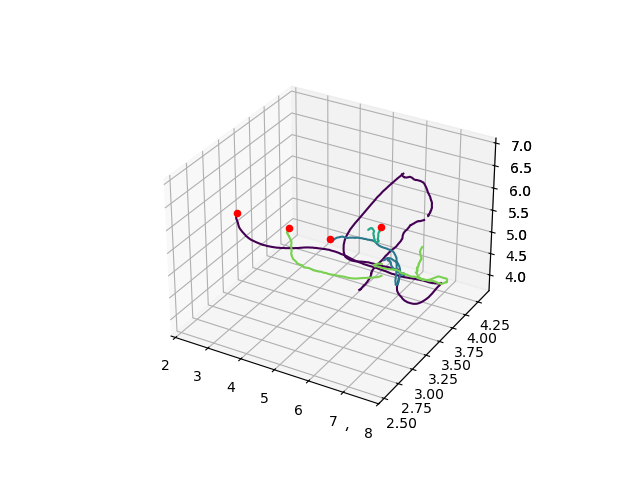

{'interaction.MOVEABLE-RESTRAINT.2': Group(key='interaction.MOVEABLE-RESTRAINT.2', particles=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], moves=[(1019317, array([[2.2542214, 3.3127725, 5.494043 ],
       [2.259307 , 3.3076391, 5.490885 ],
       [2.2620866, 3.3044064, 5.49182  ],
       [2.2659194, 3.299136 , 5.493315 ],
       [2.270722 , 3.2966576, 5.4954143],
       [2.2789342, 3.2912848, 5.494879 ],
       [2.283589 , 3.2844846, 5.4937778],
       [2.2926123, 3.285225 , 5.494617 ],
       [2.299381 , 3.2781913, 5.4889526],
       [2.30311  , 3.2741928, 5.4871235],
       [2.307258 , 3.27189  , 5.4820538],
       [2.3137434, 3.2667434, 5.4766726],
       [2.315704 , 3.2623374, 5.467502 ],
       [2.3238578, 3.2571414, 5.461553 ],
       [2.3300533, 3.2558734, 5.453293 ],
       [2.3397703, 3.2499096, 5.444134 ],
       [2.348816 , 3.250467 , 5.431814 ],
       [2.359303 , 3.248438 , 5.4192204],
       [2.3719313, 3.2465403, 5.408134 ],
       [2.3819342, 3.246867 , 5.390774 ],
       [2.

In [6]:
%matplotlib widget

import matplotlib.pyplot as plt

ax = plt.axes(projection='3d')
cmap = plt.get_cmap()

names = list(GROUPS.keys())

MAX = max(min(group.particles) for group in GROUPS.values())

for i, group in enumerate(GROUPS.values()):
    u = i / len(GROUPS)
    for timestamp, path in group.moves:
        X = path[:,0]
        Y = path[:,1]
        Z = path[:,2]
        ax.plot3D(X,Y,Z, color=cmap(u), label=f"{i} -- {group.key}")

    if group.moves:
        path = group.moves[0][1]
        X = path[:,0]
        Y = path[:,1]
        Z = path[:,2]
        ax.scatter(X[0], Y[0], Z[0], c="red")

#plt.legend()
plt.show()

print(GROUPS)